# Dimensionality Reduction: PCA, t-SNE, and UMAP

## 1. Introduction

**Dimensionality reduction** is the process of transforming high-dimensional data into a lower-dimensional representation while preserving important information.

### Why does dimensionality reduction matter?

1. **Visualization**: Humans can't visualize data in 100 dimensions, but we can see 2D or 3D plots
2. **Computational efficiency**: Fewer dimensions = faster training and less memory
3. **Noise reduction**: High-dimensional data often contains noisy dimensions that hurt performance
4. **Feature extraction**: Find the most important patterns in your data
5. **Curse of dimensionality**: Many ML algorithms struggle in high dimensions

### What we'll learn

We'll explore three fundamental techniques:

1. **PCA (Principal Component Analysis)**: Linear method that finds directions of maximum variance
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: Non-linear method for visualization
3. **UMAP (Uniform Manifold Approximation and Projection)**: Non-linear method that preserves global structure

Each has different strengths and use cases!

## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import make_swiss_roll, make_blobs, load_digits
from sklearn.preprocessing import StandardScaler
import torch
from torchvision import datasets, transforms

# Shared library
from aiml_notebooks import get_device, set_seed, reduce_dimensions

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility.

In [2]:
set_seed(42)

## 3. Generate Example Data

We'll create several datasets to demonstrate different aspects of dimensionality reduction:

1. **Simple 3D data** - easy to visualize the transformation
2. **Swiss roll** - classic non-linear manifold
3. **High-dimensional clusters** - realistic scenario
4. **MNIST digits** - real images

### 3.1 Simple 3D Ellipsoid

Let's start with 3D data where points lie on an ellipsoid. This makes it easy to see how PCA finds the principal axes.

In [3]:
# Generate 3D ellipsoid data
n_samples = 500

# Create random points on a sphere
theta = np.random.uniform(0, 2*np.pi, n_samples)
phi = np.random.uniform(0, np.pi, n_samples)

# Convert to Cartesian coordinates and stretch along different axes
X_3d = np.stack([
    3.0 * np.sin(phi) * np.cos(theta),  # x: variance = 9
    2.0 * np.sin(phi) * np.sin(theta),  # y: variance = 4
    1.0 * np.cos(phi)                    # z: variance = 1
], axis=1)

print(f"Shape: {X_3d.shape}")
print(f"Variance per dimension: {np.var(X_3d, axis=0)}")

Shape: (500, 3)
Variance per dimension: [2.308285   0.98734327 0.49392541]


Visualize the 3D ellipsoid.

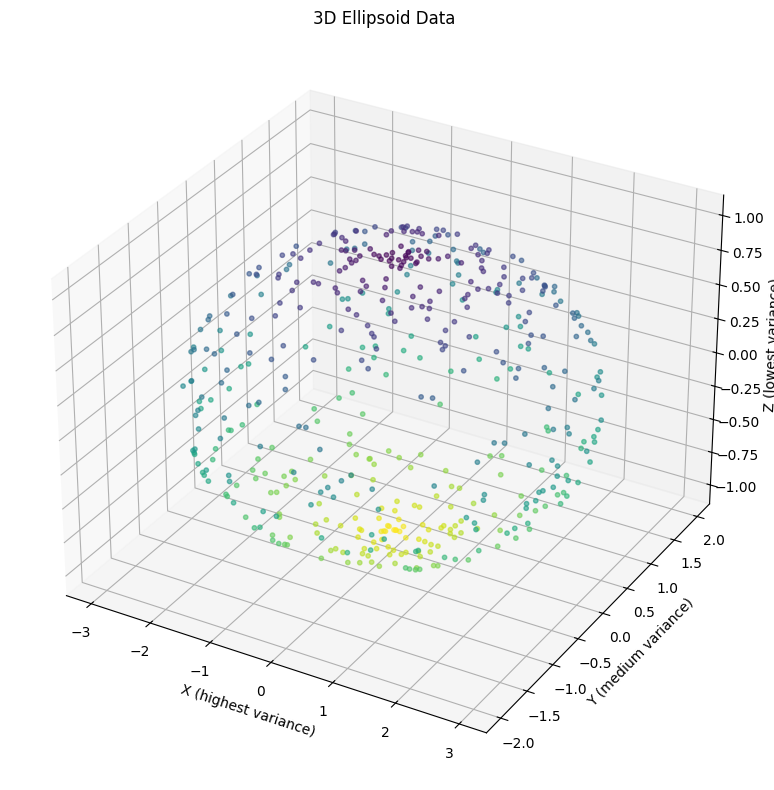

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=phi, cmap='viridis', alpha=0.6, s=10)
ax.set_xlabel('X (highest variance)')
ax.set_ylabel('Y (medium variance)')
ax.set_zlabel('Z (lowest variance)')
ax.set_title('3D Ellipsoid Data')
plt.tight_layout()
plt.show()

Notice how the data is stretched more along the X axis than Y, and even less along Z. This is exactly what PCA will discover!

### 3.2 Swiss Roll Dataset

The **Swiss roll** is a classic 2D manifold embedded in 3D space. It's curved, so linear methods like PCA won't "unroll" it properly, but non-linear methods like t-SNE and UMAP can.

In [5]:
# Generate Swiss roll
X_swiss, color_swiss = make_swiss_roll(n_samples=1500, noise=0.05, random_state=42)

print(f"Shape: {X_swiss.shape}")
print(f"Color range (position on roll): [{color_swiss.min():.2f}, {color_swiss.max():.2f}]")

Shape: (1500, 3)
Color range (position on roll): [4.76, 14.13]


Visualize the Swiss roll from different angles.

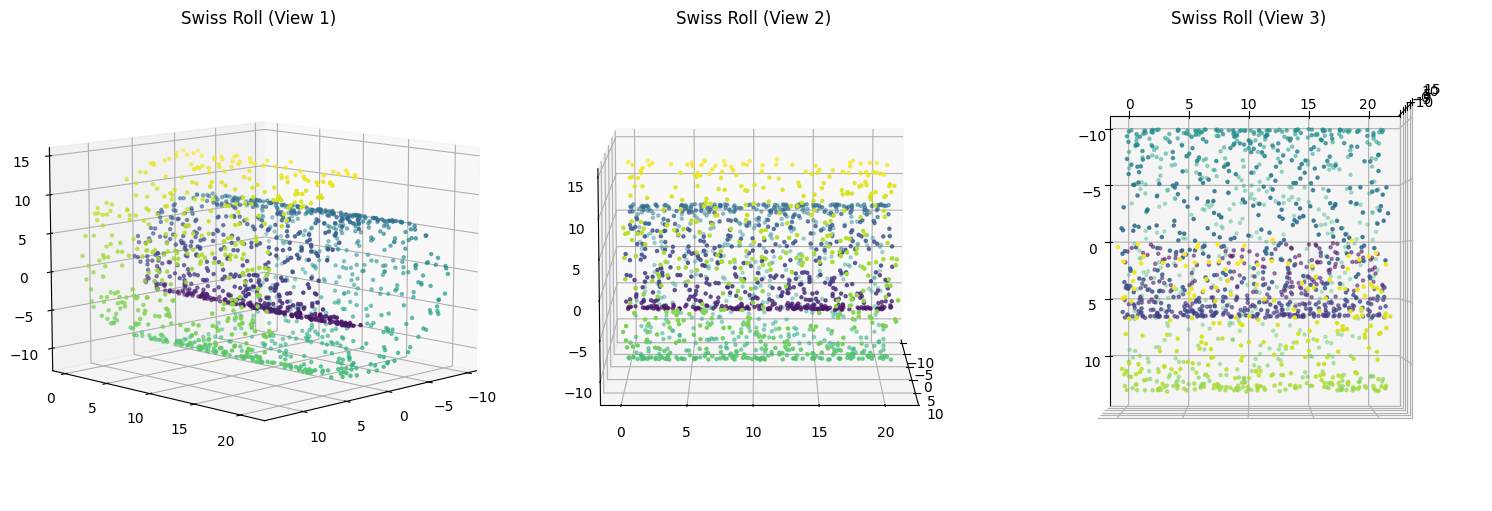

In [6]:
fig = plt.figure(figsize=(15, 5))

# View 1: Default
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=color_swiss, cmap='viridis', s=5)
ax1.set_title('Swiss Roll (View 1)')
ax1.view_init(elev=10, azim=45)

# View 2: Side view
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=color_swiss, cmap='viridis', s=5)
ax2.set_title('Swiss Roll (View 2)')
ax2.view_init(elev=10, azim=0)

# View 3: Top view
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=color_swiss, cmap='viridis', s=5)
ax3.set_title('Swiss Roll (View 3)')
ax3.view_init(elev=90, azim=0)

plt.tight_layout()
plt.show()

The color represents the "true" 2D position on the unrolled manifold. Good dimensionality reduction should preserve this structure!

### 3.3 High-Dimensional Clusters

Create 5 clusters in 50 dimensions - a more realistic scenario.

In [7]:
# Generate high-dimensional clusters
X_clusters, y_clusters = make_blobs(
    n_samples=1000,
    n_features=50,
    centers=5,
    cluster_std=2.0,
    random_state=42
)

print(f"Shape: {X_clusters.shape}")
print(f"Number of clusters: {len(np.unique(y_clusters))}")
print(f"Samples per cluster: {np.bincount(y_clusters)}")

Shape: (1000, 50)
Number of clusters: 5
Samples per cluster: [200 200 200 200 200]


We can't visualize 50 dimensions directly - that's exactly why we need dimensionality reduction!

### 3.4 MNIST Digits

Load a subset of MNIST digits (28x28 = 784 dimensions) for real-world examples.

In [8]:
# Load digits dataset (lower resolution version of MNIST: 8x8 = 64 dimensions)
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Normalize
scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)

print(f"Shape: {X_digits.shape}")
print(f"Number of classes: {len(np.unique(y_digits))}")
print(f"Classes: {np.unique(y_digits)}")

Shape: (1797, 64)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


Show some example digits.

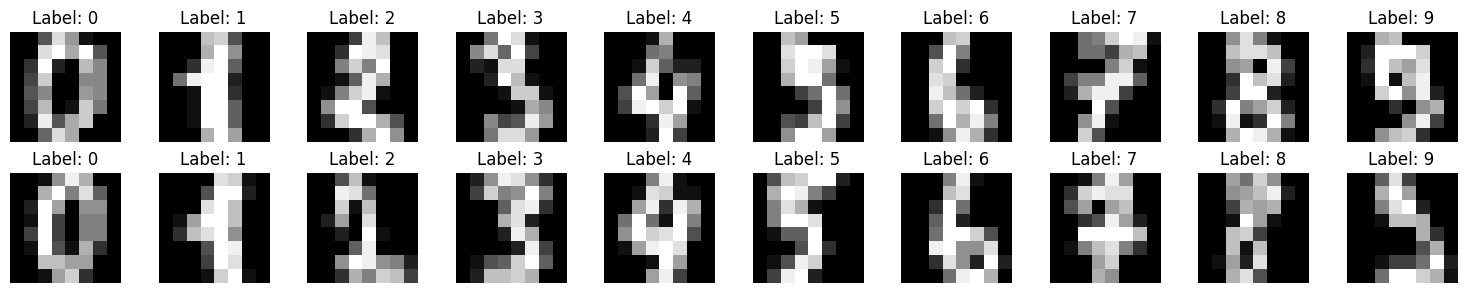

In [9]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {y_digits[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Each digit is 64 dimensions (8x8 pixels). Can we find a 2D representation that separates different digits?

## 4. PCA (Principal Component Analysis)

### 4.1 The Core Idea

**PCA** finds the directions (principal components) along which the data varies the most.

Think of it like this:
- You have a 3D cloud of points
- PCA finds the "best" 2D plane to project them onto
- "Best" means the plane that preserves the most variance

Mathematically, PCA solves this through **eigendecomposition** of the covariance matrix:

$$C = \frac{1}{n-1} X^T X$$

The eigenvectors are the principal components, and the eigenvalues tell us how much variance each component explains.

### 4.2 PCA from Scratch (Simple 2D Example)

Let's build PCA from scratch on simple 2D data to understand the mechanics.

In [10]:
# Generate correlated 2D data
np.random.seed(42)
X_2d_raw = np.random.randn(300, 2)

# Create correlation: y depends on x
X_2d = X_2d_raw @ np.array([[3, 0], [0, 1]]) + np.array([2, 3])

print(f"Shape: {X_2d.shape}")
print(f"Mean: {X_2d.mean(axis=0)}")
print(f"Std: {X_2d.std(axis=0)}")

Shape: (300, 2)
Mean: [1.96764708 2.98374576]
Std: [2.93295111 0.96506311]


Visualize the raw 2D data.

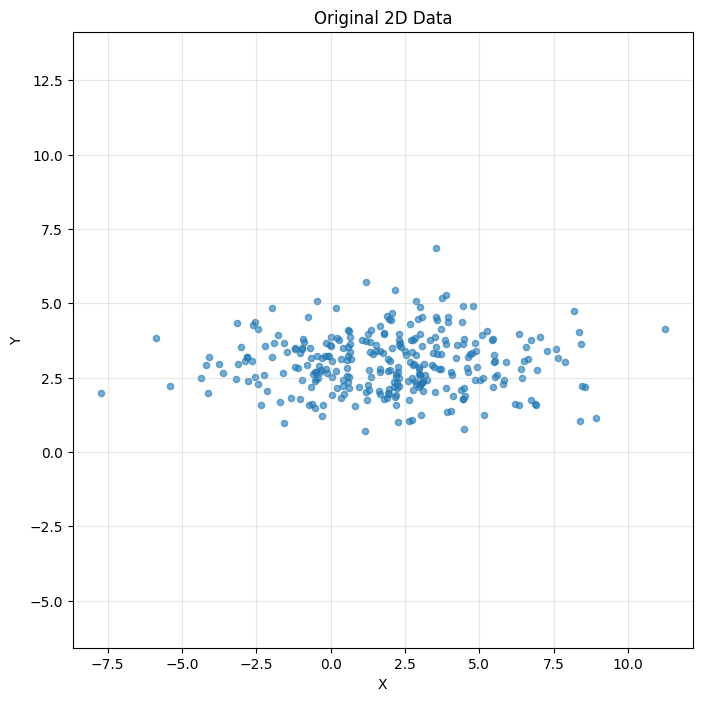

In [11]:
plt.figure(figsize=(8, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, s=20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original 2D Data')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

**Step 1**: Center the data (subtract mean).

In [12]:
# Center the data
X_centered = X_2d - X_2d.mean(axis=0)

print(f"Original mean: {X_2d.mean(axis=0)}")
print(f"Centered mean: {X_centered.mean(axis=0)}")

Original mean: [1.96764708 2.98374576]
Centered mean: [-3.38247948e-16 -2.75483340e-15]


**Step 2**: Compute the covariance matrix.

The covariance matrix $C$ captures how each dimension varies with every other dimension.

In [13]:
# Compute covariance matrix
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

print("Covariance matrix:")
print(cov_matrix)
print(f"\nDiagonal (variances): {np.diag(cov_matrix)}")
print(f"Off-diagonal (covariances): {cov_matrix[0, 1]}")

Covariance matrix:
[[8.63097211 0.03856426]
 [0.03856426 0.93446169]]

Diagonal (variances): [8.63097211 0.93446169]
Off-diagonal (covariances): 0.03856426355590731


**Step 3**: Compute eigenvectors and eigenvalues.

Eigenvectors are the principal component directions, eigenvalues are the variance along those directions.

In [14]:
# Compute eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by eigenvalue (descending)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues (variance explained):")
print(eigenvalues)
print("\nEigenvectors (principal components):")
print(eigenvectors)

Eigenvalues (variance explained):
[8.63116534 0.93426846]

Eigenvectors (principal components):
[[ 0.99998745 -0.00501043]
 [ 0.00501043  0.99998745]]


**Step 4**: Visualize the principal components on the original data.

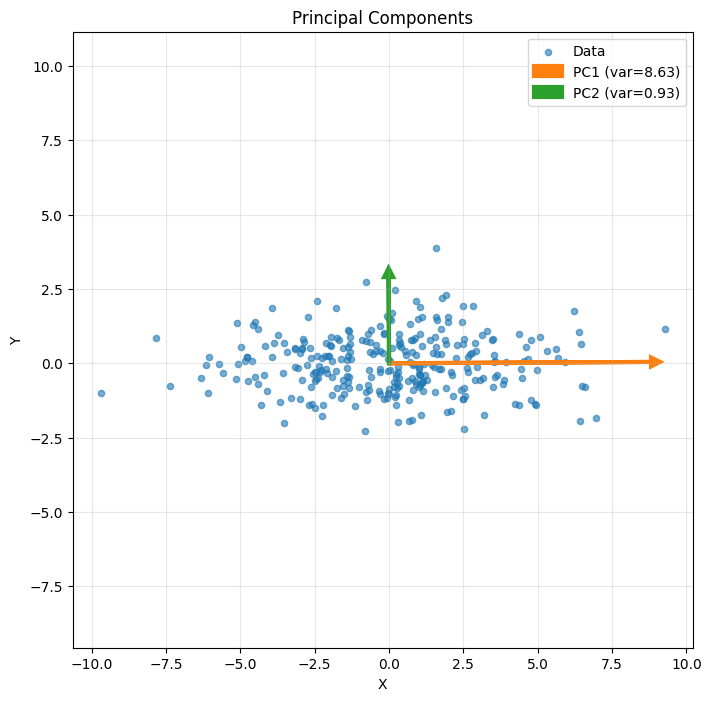

In [15]:
plt.figure(figsize=(8, 8))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6, s=20, label='Data')

# Plot principal components as arrows
origin = np.array([0, 0])
for i in range(2):
    # Scale by square root of eigenvalue (standard deviation)
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 3
    plt.arrow(origin[0], origin[1], vec[0], vec[1],
             head_width=0.3, head_length=0.3, fc=f'C{i+1}', ec=f'C{i+1}',
             linewidth=3, label=f'PC{i+1} (var={eigenvalues[i]:.2f})')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Principal Components')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

The first principal component (PC1, orange) points in the direction of maximum variance. The second (PC2, green) is orthogonal to the first.

**Step 5**: Project data onto principal components.

To reduce from 2D to 1D, we project onto just the first principal component.

In [16]:
# Project onto first principal component
X_pca_1d = X_centered @ eigenvectors[:, 0:1]

print(f"Original shape: {X_centered.shape}")
print(f"Reduced shape: {X_pca_1d.shape}")
print(f"\nFirst few values: {X_pca_1d[:5].flatten()}")

Original shape: (300, 2)
Reduced shape: (300, 1)

First few values: [ 1.52186494  1.98310621 -0.67119048  4.77385811 -1.37325307]


Visualize the projection.

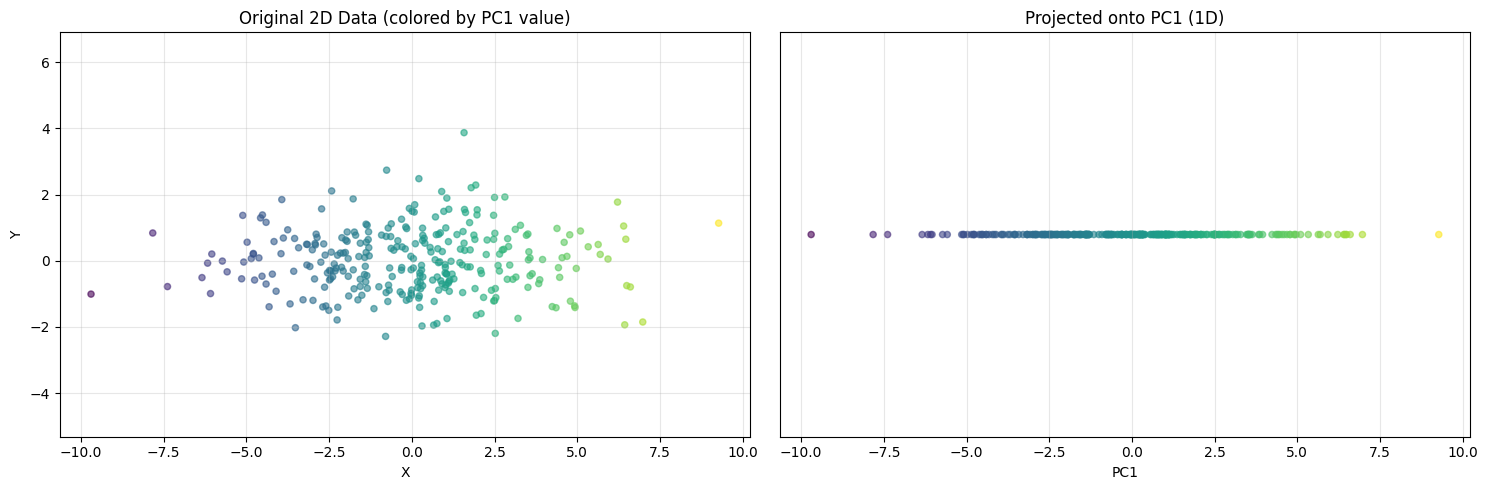

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original 2D
axes[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6, s=20, c=X_pca_1d.flatten(), cmap='viridis')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('Original 2D Data (colored by PC1 value)')
axes[0].grid(alpha=0.3)
axes[0].axis('equal')

# Projected 1D (shown on a line)
axes[1].scatter(X_pca_1d.flatten(), np.zeros_like(X_pca_1d.flatten()),
               alpha=0.6, s=20, c=X_pca_1d.flatten(), cmap='viridis')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('')
axes[1].set_title('Projected onto PC1 (1D)')
axes[1].set_yticks([])
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

We've successfully reduced from 2D to 1D while preserving the main structure of the data!

### 4.3 Variance Explained

A key question: **how much information did we lose?**

The **explained variance ratio** tells us what fraction of the total variance each component captures.

In [18]:
# Compute explained variance ratio
total_variance = eigenvalues.sum()
explained_variance_ratio = eigenvalues / total_variance

print("Explained variance ratio:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"  PC{i+1}: {ratio*100:.2f}%")

print(f"\nBy keeping only PC1, we retain {explained_variance_ratio[0]*100:.2f}% of the variance!")

Explained variance ratio:
  PC1: 90.23%
  PC2: 9.77%

By keeping only PC1, we retain 90.23% of the variance!


### 4.4 PCA on 3D Ellipsoid

Now let's apply PCA to our 3D ellipsoid and reduce it to 2D.

In [19]:
# Apply PCA using sklearn
pca_3d = PCA(n_components=2)
X_3d_reduced = pca_3d.fit_transform(X_3d)

print(f"Original shape: {X_3d.shape}")
print(f"Reduced shape: {X_3d_reduced.shape}")
print(f"\nExplained variance ratio: {pca_3d.explained_variance_ratio_}")
print(f"Total variance retained: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

Original shape: (500, 3)
Reduced shape: (500, 2)

Explained variance ratio: [0.6096528  0.26066632]
Total variance retained: 87.03%


Visualize the original 3D and reduced 2D side by side.

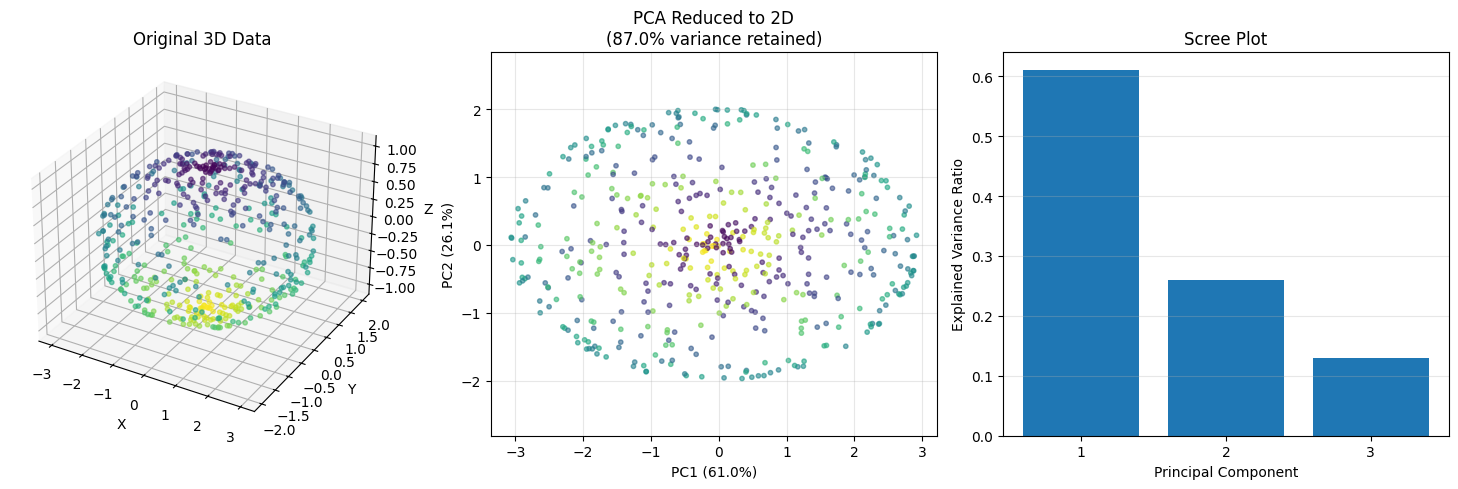

In [20]:
fig = plt.figure(figsize=(15, 5))

# Original 3D
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=phi, cmap='viridis', alpha=0.6, s=10)
ax1.set_title('Original 3D Data')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# PCA 2D
ax2 = fig.add_subplot(132)
ax2.scatter(X_3d_reduced[:, 0], X_3d_reduced[:, 1], c=phi, cmap='viridis', alpha=0.6, s=10)
ax2.set_title(f'PCA Reduced to 2D\n({pca_3d.explained_variance_ratio_.sum()*100:.1f}% variance retained)')
ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax2.grid(alpha=0.3)
ax2.axis('equal')

# Scree plot
ax3 = fig.add_subplot(133)
pca_full = PCA().fit(X_3d)
ax3.bar(range(1, 4), pca_full.explained_variance_ratio_)
ax3.set_xlabel('Principal Component')
ax3.set_ylabel('Explained Variance Ratio')
ax3.set_title('Scree Plot')
ax3.set_xticks([1, 2, 3])
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

The **scree plot** shows that PC1 and PC2 capture most of the variance, while PC3 captures very little. This tells us the data is essentially 2D!

### 4.5 PCA on Swiss Roll (Linear Method Fails)

What happens when we apply PCA to the Swiss roll? Remember, it's a curved manifold, so linear PCA won't "unroll" it.

In [21]:
# Apply PCA to Swiss roll
pca_swiss = PCA(n_components=2)
X_swiss_pca = pca_swiss.fit_transform(X_swiss)

print(f"Explained variance ratio: {pca_swiss.explained_variance_ratio_}")
print(f"Total variance retained: {pca_swiss.explained_variance_ratio_.sum()*100:.2f}%")

Explained variance ratio: [0.40740804 0.30603887]
Total variance retained: 71.34%


Visualize PCA on Swiss roll.

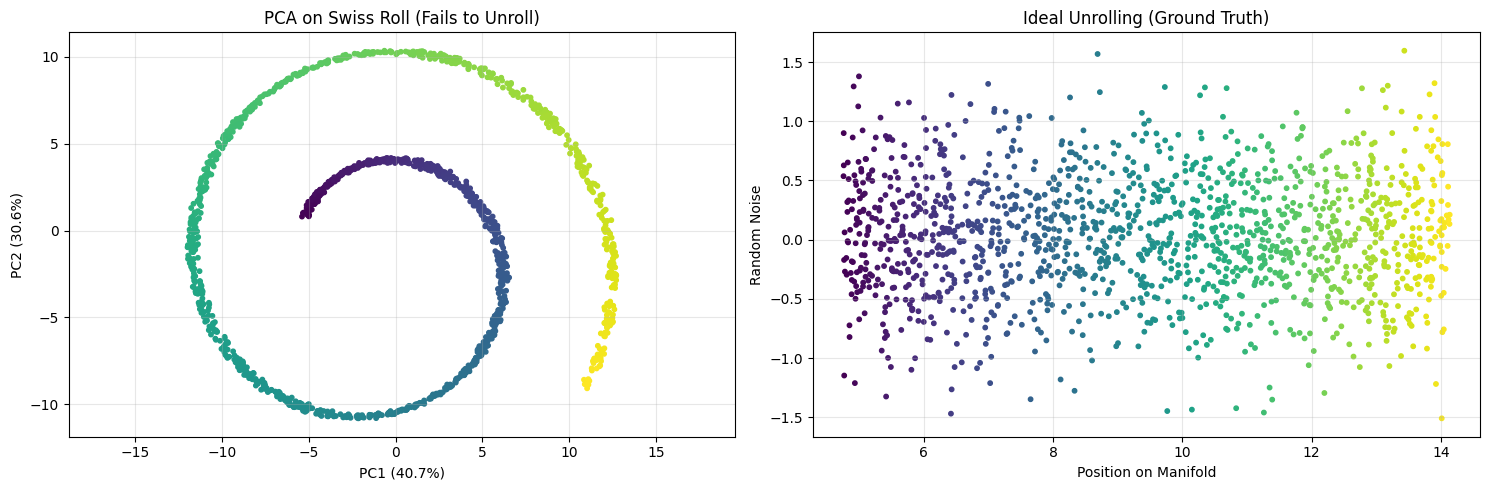

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PCA result
axes[0].scatter(X_swiss_pca[:, 0], X_swiss_pca[:, 1], c=color_swiss, cmap='viridis', s=10)
axes[0].set_title('PCA on Swiss Roll (Fails to Unroll)')
axes[0].set_xlabel(f'PC1 ({pca_swiss.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_swiss.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].grid(alpha=0.3)
axes[0].axis('equal')

# What we'd want: unrolled version
axes[1].scatter(color_swiss, np.random.randn(len(color_swiss))*0.5, c=color_swiss, cmap='viridis', s=10)
axes[1].set_title('Ideal Unrolling (Ground Truth)')
axes[1].set_xlabel('Position on Manifold')
axes[1].set_ylabel('Random Noise')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**PCA failed!** It just rotated the Swiss roll but didn't unroll it. The colors are still mixed up.

This is because PCA is a **linear** method - it can't capture the curved structure. We need non-linear methods!

### 4.6 PCA on High-Dimensional Clusters

Let's see how PCA works on our 50-dimensional cluster data.

In [23]:
# Apply PCA
pca_clusters = PCA(n_components=2)
X_clusters_pca = pca_clusters.fit_transform(X_clusters)

print(f"Original shape: {X_clusters.shape}")
print(f"Reduced shape: {X_clusters_pca.shape}")
print(f"\nExplained variance ratio: {pca_clusters.explained_variance_ratio_}")
print(f"Total variance retained: {pca_clusters.explained_variance_ratio_.sum()*100:.2f}%")

Original shape: (1000, 50)
Reduced shape: (1000, 2)

Explained variance ratio: [0.28087707 0.24563488]
Total variance retained: 52.65%


Visualize the clusters in 2D.

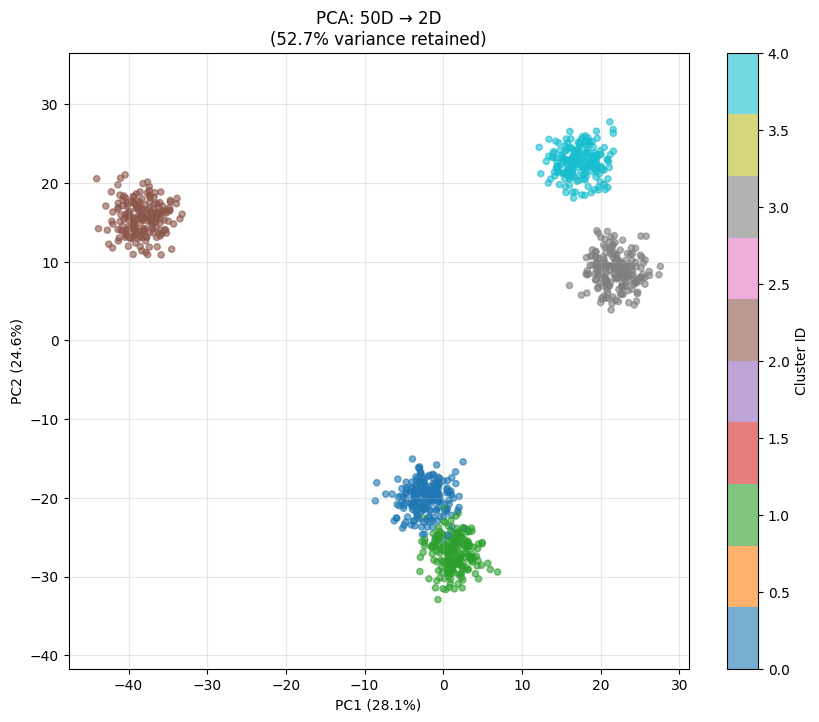

In [24]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_clusters_pca[:, 0], X_clusters_pca[:, 1],
                     c=y_clusters, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel(f'PC1 ({pca_clusters.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_clusters.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'PCA: 50D → 2D\n({pca_clusters.explained_variance_ratio_.sum()*100:.1f}% variance retained)')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

Nice! The 5 clusters are clearly separated even after reducing from 50D to 2D. This is because the clusters are well-separated in the high-dimensional space.

## 5. t-SNE (t-Distributed Stochastic Neighbor Embedding)

### 5.1 The Core Idea

**t-SNE** is a non-linear method designed specifically for visualization. It excels at preserving **local structure** - keeping similar points together.

Key intuition:
1. In high dimensions, compute pairwise similarities between points
2. In low dimensions, try to preserve those similarities
3. Use a "heavy-tailed" distribution (t-distribution) to avoid crowding

The main hyperparameter is **perplexity**, which roughly corresponds to how many neighbors each point should have (typically 5-50).

### 5.2 t-SNE on Swiss Roll

Let's see if t-SNE can unroll the Swiss roll where PCA failed.

In [25]:
# Apply t-SNE
tsne_swiss = TSNE(n_components=2, perplexity=30, random_state=42)
X_swiss_tsne = tsne_swiss.fit_transform(X_swiss)

print(f"Original shape: {X_swiss.shape}")
print(f"Reduced shape: {X_swiss_tsne.shape}")

Original shape: (1500, 3)
Reduced shape: (1500, 2)


Compare t-SNE vs PCA on the Swiss roll.

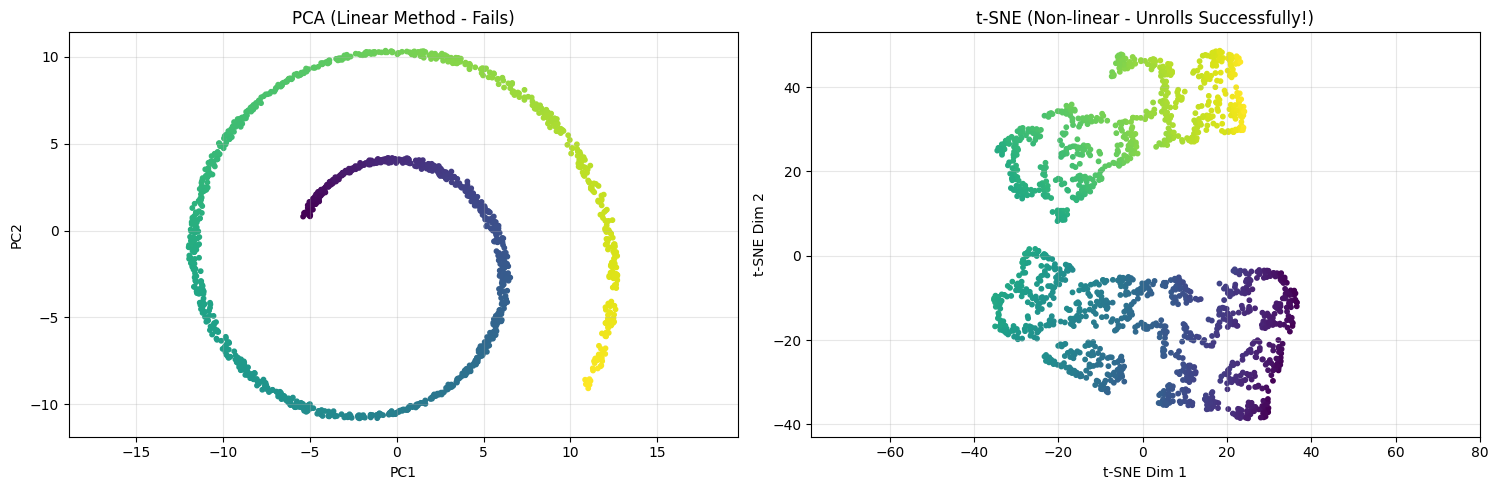

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PCA (linear - fails)
axes[0].scatter(X_swiss_pca[:, 0], X_swiss_pca[:, 1], c=color_swiss, cmap='viridis', s=10)
axes[0].set_title('PCA (Linear Method - Fails)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.3)
axes[0].axis('equal')

# t-SNE (non-linear - succeeds!)
axes[1].scatter(X_swiss_tsne[:, 0], X_swiss_tsne[:, 1], c=color_swiss, cmap='viridis', s=10)
axes[1].set_title('t-SNE (Non-linear - Unrolls Successfully!)')
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
axes[1].grid(alpha=0.3)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

**t-SNE successfully unrolled the Swiss roll!** Notice how the colors form a smooth gradient - nearby points on the manifold stay nearby in the 2D embedding.

### 5.3 The Impact of Perplexity

**Perplexity** is t-SNE's most important parameter. It balances attention between local and global structure.

- Low perplexity (5-10): Focus on very local structure, may create many small clusters
- High perplexity (30-50): Consider more neighbors, smoother embedding
- Too high: May lose structure

In [27]:
# Try different perplexity values
perplexities = [5, 30, 50]
tsne_results = {}

for perp in perplexities:
    print(f"Running t-SNE with perplexity={perp}...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    tsne_results[perp] = tsne.fit_transform(X_clusters)

Running t-SNE with perplexity=5...


Running t-SNE with perplexity=30...


Running t-SNE with perplexity=50...


Visualize the effect of different perplexity values.

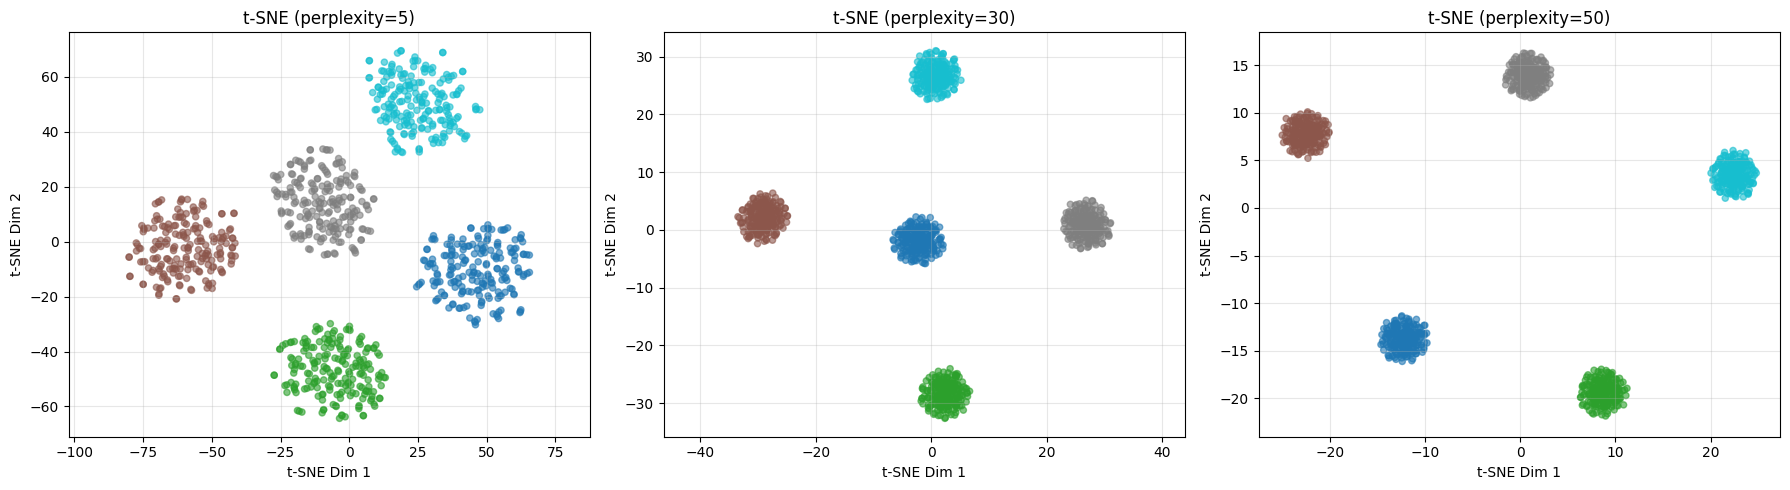

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, perplexities):
    X_embedded = tsne_results[perp]
    ax.scatter(X_embedded[:, 0], X_embedded[:, 1],
              c=y_clusters, cmap='tab10', alpha=0.6, s=20)
    ax.set_title(f't-SNE (perplexity={perp})')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    ax.grid(alpha=0.3)
    ax.axis('equal')

plt.tight_layout()
plt.show()

Notice:
- **Perplexity=5**: Very tight clusters, but may fragment larger clusters
- **Perplexity=30**: Good balance, clusters are clear and well-separated
- **Perplexity=50**: Smoother, but clusters may start to merge

Rule of thumb: Start with perplexity=30 for most datasets.

### 5.4 t-SNE on Digits Dataset

Let's visualize the digit dataset (64 dimensions → 2 dimensions).

In [29]:
# Apply t-SNE to digits
print("Running t-SNE on digits dataset...")
tsne_digits = TSNE(n_components=2, perplexity=30, random_state=42)
X_digits_tsne = tsne_digits.fit_transform(X_digits_scaled)

print(f"Reduced shape: {X_digits_tsne.shape}")

Running t-SNE on digits dataset...


Reduced shape: (1797, 2)


Visualize the digit embeddings.

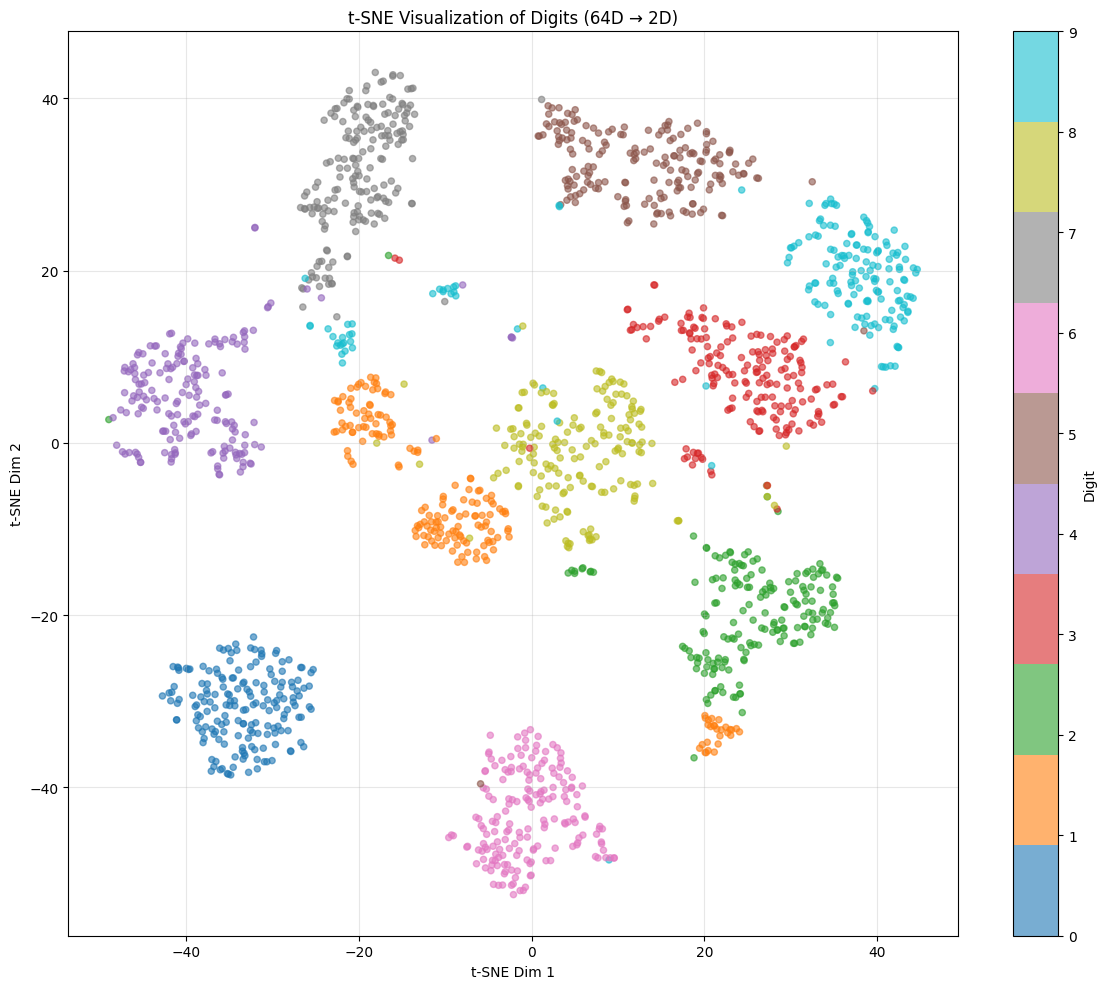

In [30]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1],
                     c=y_digits, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Digit', ticks=range(10))
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.title('t-SNE Visualization of Digits (64D → 2D)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Beautiful!** Each digit forms its own cluster. Similar digits (like 3 and 8, or 4 and 9) are closer together.

This shows that t-SNE successfully captured the semantic structure of the data!

## 6. UMAP (Uniform Manifold Approximation and Projection)

### 6.1 The Core Idea

**UMAP** is a newer algorithm that aims to preserve both **local and global structure** better than t-SNE.

Key advantages over t-SNE:
1. **Faster**: Can handle larger datasets
2. **Better global structure**: Preserves distances between clusters more accurately
3. **More stable**: Less sensitive to hyperparameters
4. **Can embed new points**: t-SNE requires re-running on the entire dataset

Main hyperparameters:
- `n_neighbors`: Similar to perplexity in t-SNE (default: 15)
- `min_dist`: Minimum distance between points in the embedding (default: 0.1)

### 6.2 UMAP on Swiss Roll

In [31]:
# Apply UMAP using the shared library
print("Running UMAP on Swiss roll...")
X_swiss_umap = reduce_dimensions(X_swiss, method='umap', n_components=2, n_neighbors=30)

Running UMAP on Swiss roll...


Running UMAP dimensionality reduction...


/home/user/aiml-notebooks/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Compare all three methods on the Swiss roll.

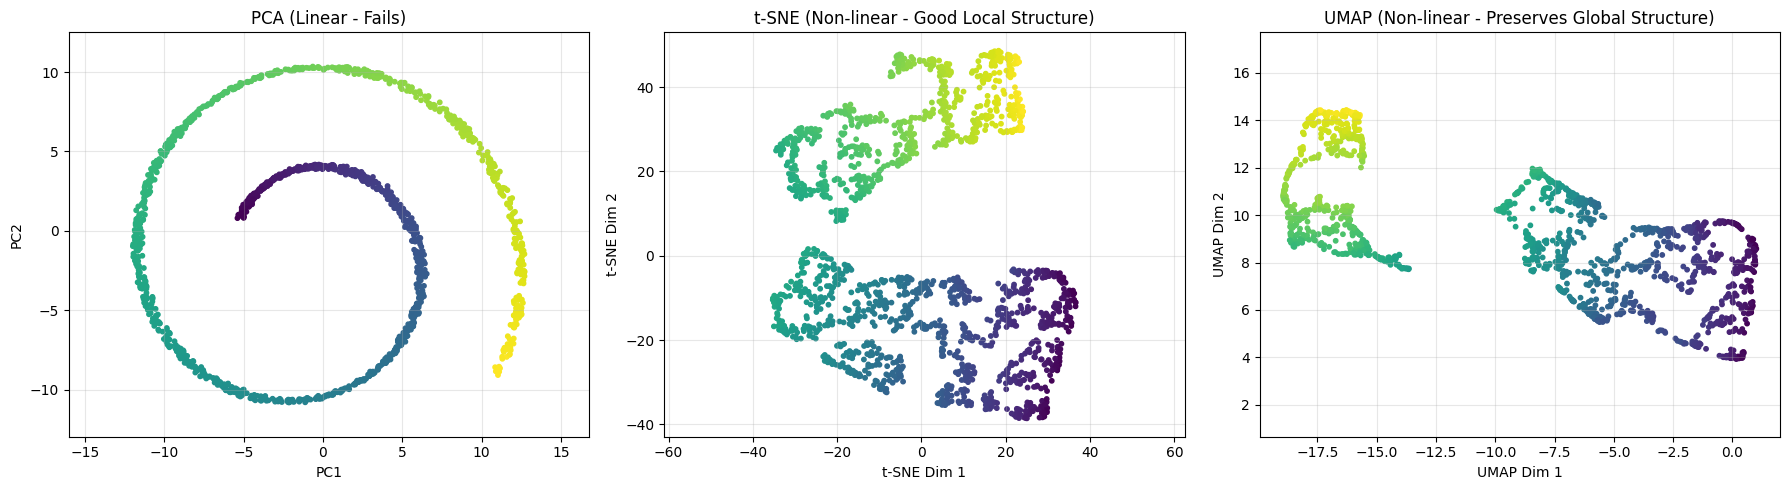

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
axes[0].scatter(X_swiss_pca[:, 0], X_swiss_pca[:, 1], c=color_swiss, cmap='viridis', s=10)
axes[0].set_title('PCA (Linear - Fails)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.3)
axes[0].axis('equal')

# t-SNE
axes[1].scatter(X_swiss_tsne[:, 0], X_swiss_tsne[:, 1], c=color_swiss, cmap='viridis', s=10)
axes[1].set_title('t-SNE (Non-linear - Good Local Structure)')
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
axes[1].grid(alpha=0.3)
axes[1].axis('equal')

# UMAP
axes[2].scatter(X_swiss_umap[:, 0], X_swiss_umap[:, 1], c=color_swiss, cmap='viridis', s=10)
axes[2].set_title('UMAP (Non-linear - Preserves Global Structure)')
axes[2].set_xlabel('UMAP Dim 1')
axes[2].set_ylabel('UMAP Dim 2')
axes[2].grid(alpha=0.3)
axes[2].axis('equal')

plt.tight_layout()
plt.show()

Both t-SNE and UMAP successfully unroll the Swiss roll, but UMAP tends to be more "spread out" and preserve the overall shape better.

### 6.3 UMAP on High-Dimensional Clusters

In [33]:
# Apply UMAP
print("Running UMAP on clusters...")
X_clusters_umap = reduce_dimensions(X_clusters, method='umap', n_components=2, n_neighbors=15)

Running UMAP on clusters...
Running UMAP dimensionality reduction...


/home/user/aiml-notebooks/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/user/aiml-notebooks/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Compare PCA, t-SNE, and UMAP on the cluster data.

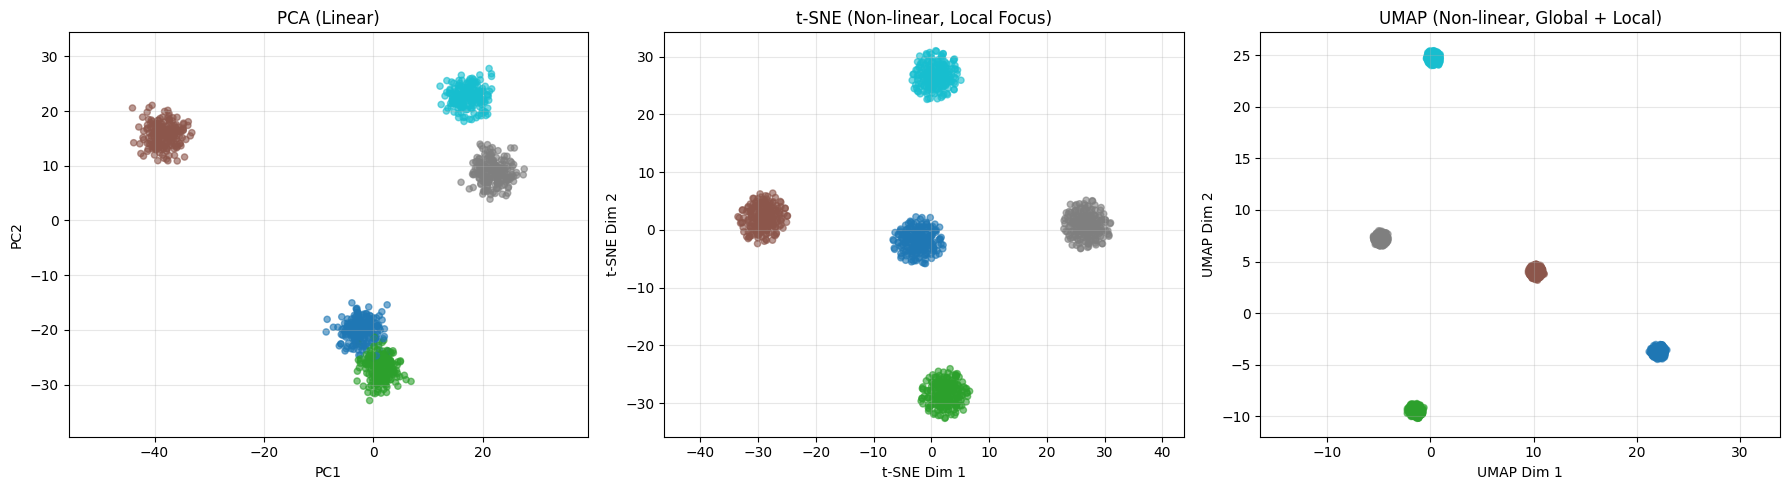

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
axes[0].scatter(X_clusters_pca[:, 0], X_clusters_pca[:, 1],
               c=y_clusters, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('PCA (Linear)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.3)
axes[0].axis('equal')

# t-SNE
axes[1].scatter(tsne_results[30][:, 0], tsne_results[30][:, 1],
               c=y_clusters, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title('t-SNE (Non-linear, Local Focus)')
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
axes[1].grid(alpha=0.3)
axes[1].axis('equal')

# UMAP
axes[2].scatter(X_clusters_umap[:, 0], X_clusters_umap[:, 1],
               c=y_clusters, cmap='tab10', alpha=0.6, s=20)
axes[2].set_title('UMAP (Non-linear, Global + Local)')
axes[2].set_xlabel('UMAP Dim 1')
axes[2].set_ylabel('UMAP Dim 2')
axes[2].grid(alpha=0.3)
axes[2].axis('equal')

plt.tight_layout()
plt.show()

Notice:
- **PCA**: Clusters are separated but overlap somewhat
- **t-SNE**: Very tight, distinct clusters (great for visualization!)
- **UMAP**: Balanced - clusters are separated but distances between clusters are more meaningful

### 6.4 UMAP on Digits Dataset

In [35]:
# Apply UMAP to digits
print("Running UMAP on digits...")
X_digits_umap = reduce_dimensions(X_digits_scaled, method='umap', n_components=2, n_neighbors=15)

Running UMAP on digits...
Running UMAP dimensionality reduction...


/home/user/aiml-notebooks/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Compare t-SNE and UMAP on digits.

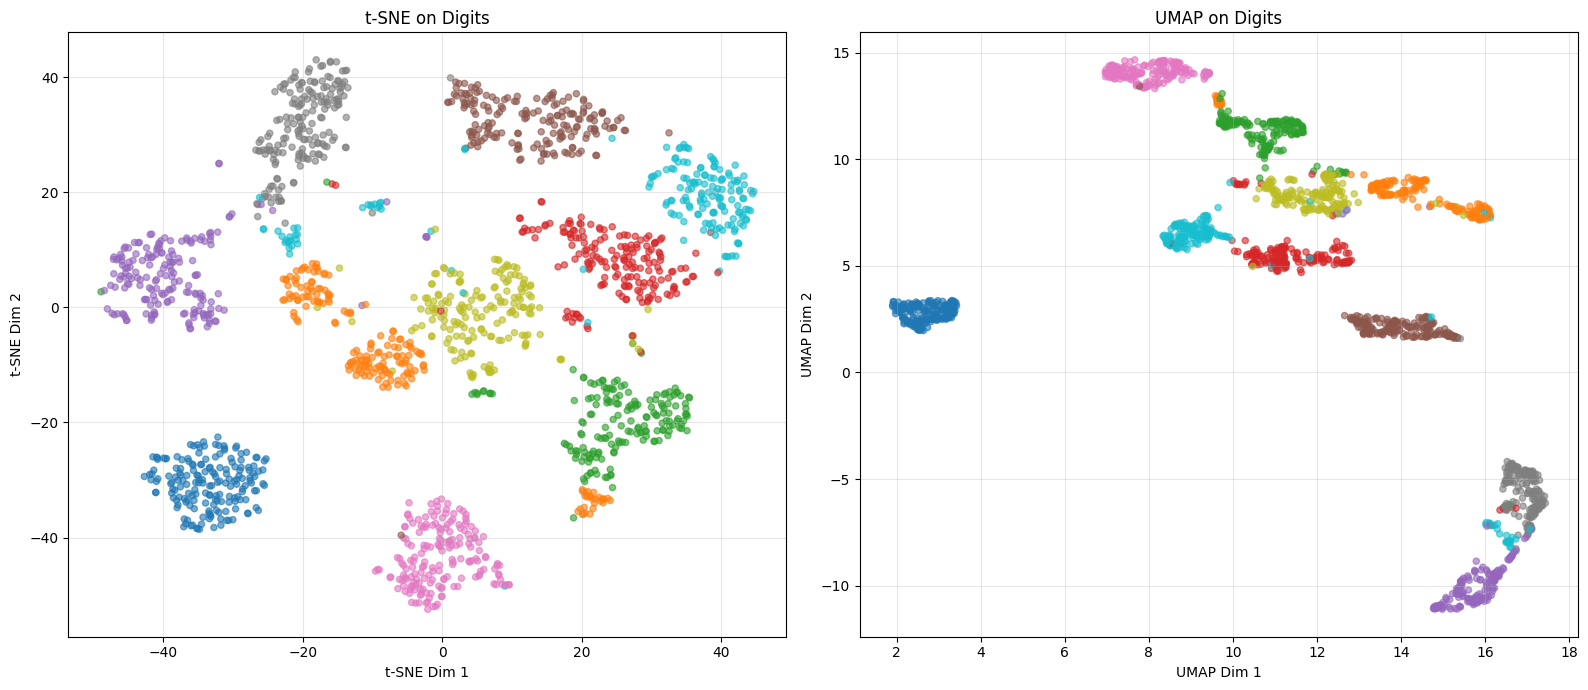

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# t-SNE
axes[0].scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1],
               c=y_digits, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('t-SNE on Digits')
axes[0].set_xlabel('t-SNE Dim 1')
axes[0].set_ylabel('t-SNE Dim 2')
axes[0].grid(alpha=0.3)

# UMAP
axes[1].scatter(X_digits_umap[:, 0], X_digits_umap[:, 1],
               c=y_digits, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title('UMAP on Digits')
axes[1].set_xlabel('UMAP Dim 1')
axes[1].set_ylabel('UMAP Dim 2')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Both create clear digit clusters, but UMAP:
- Is faster to compute
- Preserves more global structure (distances between clusters are more meaningful)
- Can be used to transform new points without recomputing the entire embedding

## 7. Applications of Dimensionality Reduction

### 7.1 Application 1: Visualization

The most common use case - making high-dimensional data visible to humans!

We've already seen this throughout! Let's create one comprehensive visualization showing the power of this.

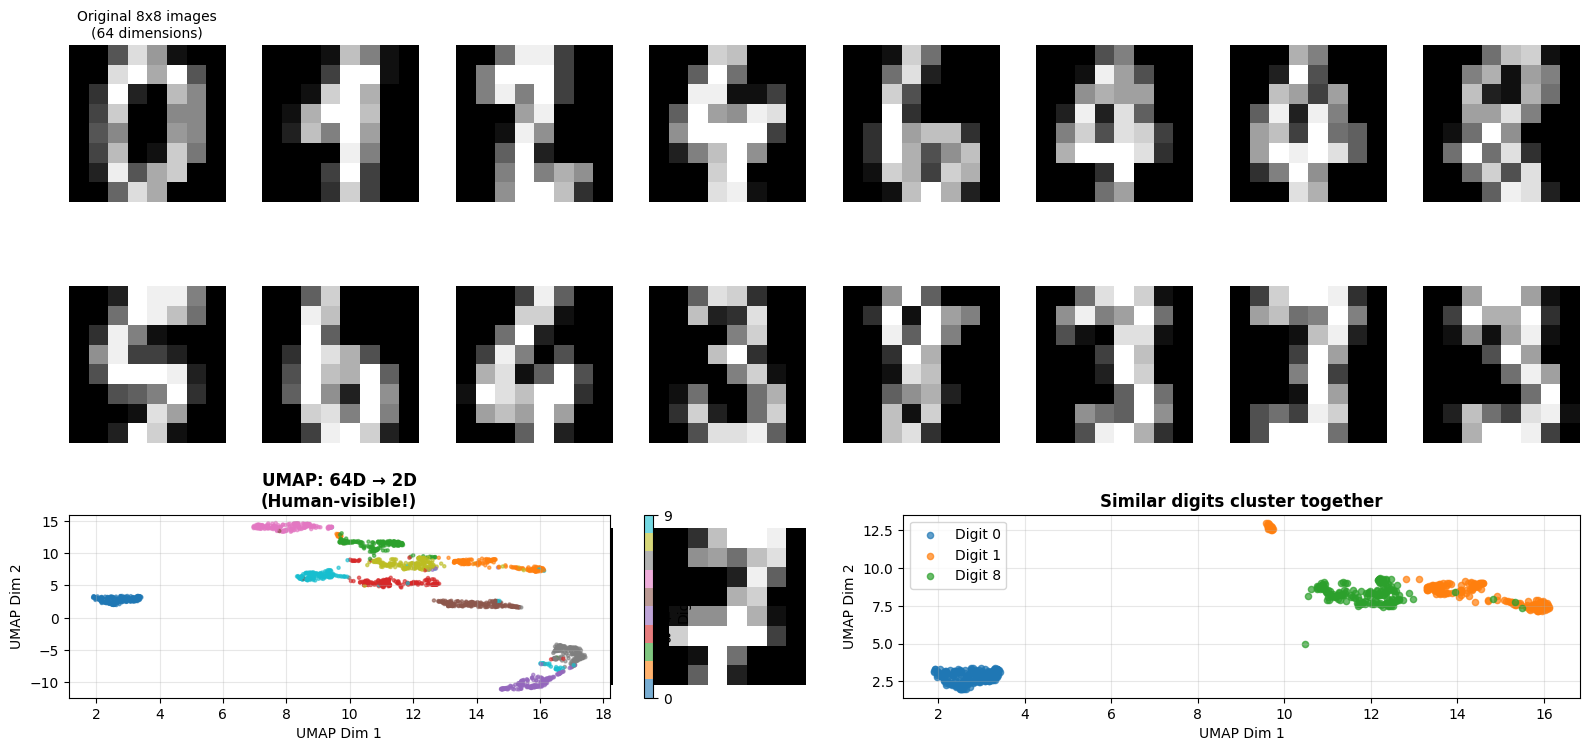

From 64 dimensions (impossible to visualize) to 2 dimensions (easy to understand)!


In [37]:
fig = plt.figure(figsize=(16, 12))

# Show some original digit images
for i in range(20):
    ax = fig.add_subplot(5, 8, i+1)
    ax.imshow(digits.images[i*90], cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title('Original 8x8 images\n(64 dimensions)', fontsize=10)

# Show UMAP embedding
ax = fig.add_subplot(5, 2, 5)
scatter = ax.scatter(X_digits_umap[:, 0], X_digits_umap[:, 1],
                    c=y_digits, cmap='tab10', alpha=0.6, s=5)
ax.set_title('UMAP: 64D → 2D\n(Human-visible!)', fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP Dim 1')
ax.set_ylabel('UMAP Dim 2')
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Digit', ticks=range(10))

# Show that similar digits cluster together
ax = fig.add_subplot(5, 2, 6)
# Highlight just 0s, 1s, and 8s
mask = np.isin(y_digits, [0, 1, 8])
for digit in [0, 1, 8]:
    mask_digit = y_digits == digit
    ax.scatter(X_digits_umap[mask_digit, 0], X_digits_umap[mask_digit, 1],
              label=f'Digit {digit}', alpha=0.7, s=20)
ax.set_title('Similar digits cluster together', fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP Dim 1')
ax.set_ylabel('UMAP Dim 2')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("From 64 dimensions (impossible to visualize) to 2 dimensions (easy to understand)!")

### 7.2 Application 2: Feature Extraction

Use PCA to extract the most important features, then train a classifier on the reduced data.

This can speed up training and sometimes improve generalization!

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_digits_scaled, y_digits, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1437, 64)
Test set: (360, 64)


Compare classification performance with different numbers of PCA components.

In [39]:
n_components_list = [2, 5, 10, 20, 30, 64]  # 64 = all components (no reduction)
accuracies = []
explained_variance = []

for n_comp in n_components_list:
    # Apply PCA
    pca = PCA(n_components=n_comp if n_comp < 64 else None)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Train classifier
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_pca, y_train)
    
    # Evaluate
    y_pred = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    var_explained = pca.explained_variance_ratio_.sum()
    explained_variance.append(var_explained)
    
    print(f"n_components={n_comp:2d}: accuracy={acc:.4f}, variance explained={var_explained:.4f}")

n_components= 2: accuracy=0.5278, variance explained=0.2138
n_components= 5: accuracy=0.8139, variance explained=0.4098
n_components=10: accuracy=0.8833, variance explained=0.5887
n_components=20: accuracy=0.9417, variance explained=0.7966
n_components=30: accuracy=0.9639, variance explained=0.8962
n_components=64: accuracy=0.9722, variance explained=1.0000


Visualize the accuracy vs number of components tradeoff.

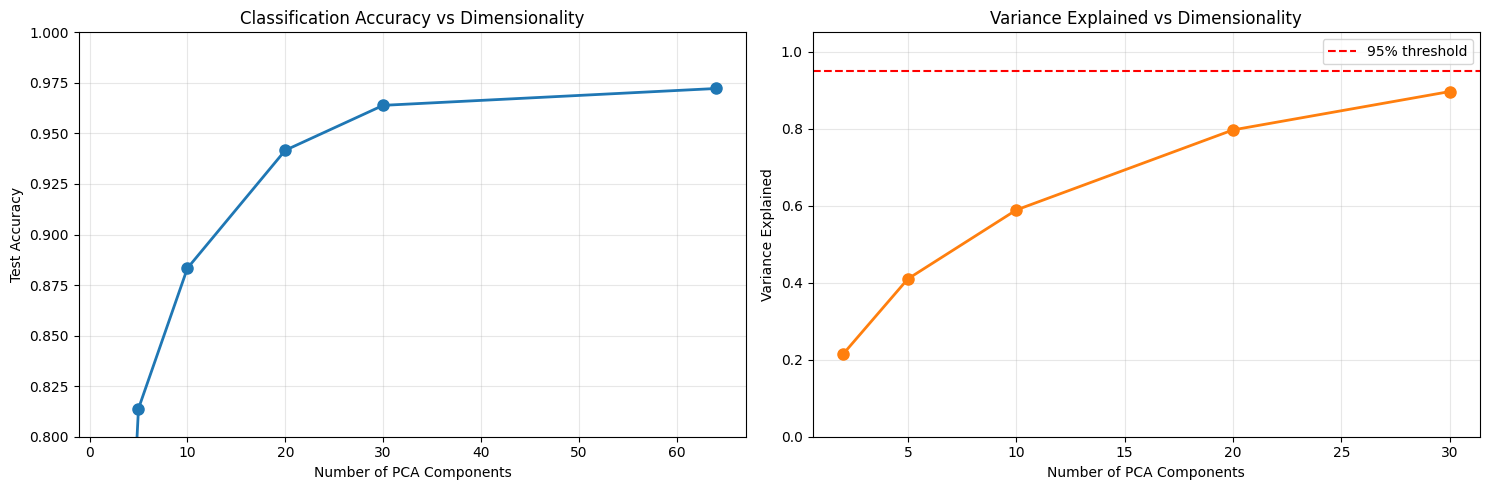


Key insight: With just 20 components (31% of original), we get 94.17% accuracy!


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy vs components
axes[0].plot(n_components_list, accuracies, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of PCA Components')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Classification Accuracy vs Dimensionality')
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0.8, 1.0])

# Variance explained vs components
axes[1].plot(n_components_list[:-1], explained_variance[:-1], marker='o', linewidth=2, markersize=8, color='C1')
axes[1].set_xlabel('Number of PCA Components')
axes[1].set_ylabel('Variance Explained')
axes[1].set_title('Variance Explained vs Dimensionality')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.05])
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nKey insight: With just 20 components (31% of original), we get {accuracies[3]:.2%} accuracy!")

**Key takeaway**: We can reduce from 64 to 20 dimensions while keeping ~96% accuracy. That's 3x fewer features with minimal performance loss!

### 7.3 Application 3: Noise Reduction

PCA can filter out noisy dimensions by projecting onto the principal components and reconstructing.

This works because noise is typically spread across all dimensions, while signal concentrates in a few.

In [41]:
# Add noise to some digit images
np.random.seed(42)
noise_level = 3.0
X_digits_noisy = X_digits + np.random.randn(*X_digits.shape) * noise_level

# Standardize both
scaler_noisy = StandardScaler()
X_digits_noisy_scaled = scaler_noisy.fit_transform(X_digits_noisy)

print(f"Noise level (std): {noise_level}")
print(f"Signal std: {X_digits.std():.2f}")
print(f"Signal-to-noise ratio: {X_digits.std() / noise_level:.2f}")

Noise level (std): 3.0
Signal std: 6.02
Signal-to-noise ratio: 2.01


Apply PCA denoising: project onto top components, then reconstruct.

In [42]:
# Use PCA for denoising
n_components_denoise = 20  # Keep only top 20 components

pca_denoise = PCA(n_components=n_components_denoise)
X_digits_denoised_scaled = pca_denoise.fit_transform(X_digits_noisy_scaled)
X_digits_denoised_scaled = pca_denoise.inverse_transform(X_digits_denoised_scaled)

# Transform back to original scale
X_digits_denoised = scaler_noisy.inverse_transform(X_digits_denoised_scaled)

print(f"Variance explained by {n_components_denoise} components: {pca_denoise.explained_variance_ratio_.sum():.2%}")

Variance explained by 20 components: 59.12%


Compare original, noisy, and denoised images.

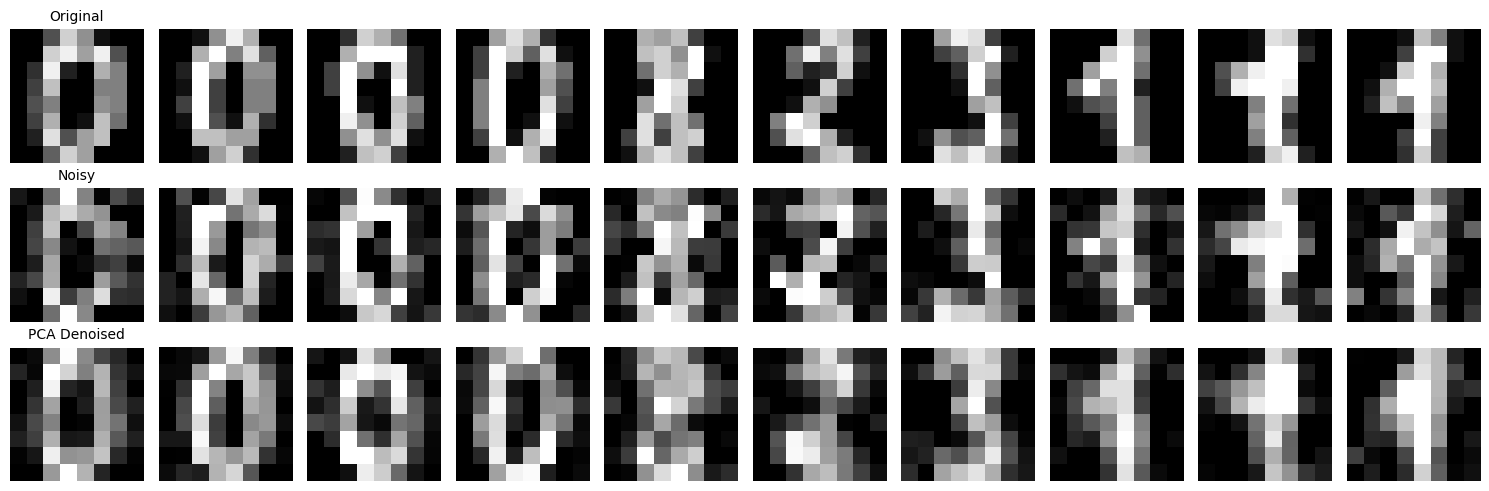

In [43]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

indices = range(0, 100, 10)  # Show 10 examples

for i, idx in enumerate(indices):
    # Original
    axes[0, i].imshow(X_digits[idx].reshape(8, 8), cmap='gray', vmin=0, vmax=16)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)
    
    # Noisy
    axes[1, i].imshow(X_digits_noisy[idx].reshape(8, 8), cmap='gray', vmin=0, vmax=16)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Noisy', fontsize=10)
    
    # Denoised
    axes[2, i].imshow(X_digits_denoised[idx].reshape(8, 8), cmap='gray', vmin=0, vmax=16)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('PCA Denoised', fontsize=10)

plt.tight_layout()
plt.show()

Compute reconstruction error to quantify denoising quality.

In [44]:
# Mean squared error
mse_noisy = np.mean((X_digits - X_digits_noisy)**2)
mse_denoised = np.mean((X_digits - X_digits_denoised)**2)

print(f"MSE (noisy vs original): {mse_noisy:.4f}")
print(f"MSE (denoised vs original): {mse_denoised:.4f}")
print(f"\nImprovement: {(1 - mse_denoised/mse_noisy)*100:.1f}% reduction in error")

MSE (noisy vs original): 9.0067
MSE (denoised vs original): 7.3395

Improvement: 18.5% reduction in error


**PCA successfully removed noise!** By keeping only the top 20 components (which capture the signal), we filtered out the noise spread across all dimensions.

## 8. Comparison and When to Use Each Method

Let's summarize the strengths and use cases of each method.

### 8.1 Side-by-Side Comparison

| Method | Type | Speed | Preserves | Best For | Limitations |
|--------|------|-------|-----------|----------|-------------|
| **PCA** | Linear | Fast ⚡⚡⚡ | Global variance | Feature extraction, preprocessing, linear data | Can't capture non-linear structure |
| **t-SNE** | Non-linear | Slow 🐌 | Local structure | Visualization, cluster discovery | Destroys global distances, can't transform new points |
| **UMAP** | Non-linear | Fast ⚡⚡ | Local + Global | Visualization, clustering, embeddings | More complex, harder to tune |

### 8.2 Decision Guide

**Use PCA when:**
- You need to speed up training (feature extraction)
- You want to denoise data
- You care about explained variance
- Your data has linear structure
- You need to transform new data points

**Use t-SNE when:**
- Visualization is your primary goal
- You want to discover hidden clusters
- You don't care about distances between clusters
- Your dataset is relatively small (<10k points)
- You only need to embed once (not for new points)

**Use UMAP when:**
- You want both local and global structure
- Your dataset is large (>10k points)
- You need to embed new points later
- You want meaningful distances between clusters
- Speed matters

### 8.3 Common Workflow

In practice, you might use multiple methods:

1. **Start with PCA**: Get a baseline, check explained variance
2. **Try t-SNE**: For beautiful visualizations and cluster discovery
3. **Use UMAP**: For production embeddings or large datasets
4. **Feature extraction**: Use PCA → feed reduced features to your model

In [45]:
# Example workflow: PCA + UMAP
print("Example workflow: PCA → UMAP for very high dimensions\n")

# Step 1: Use PCA to reduce from 64 → 30 dimensions (fast)
pca_intermediate = PCA(n_components=30)
X_pca_intermediate = pca_intermediate.fit_transform(X_digits_scaled)
print(f"Step 1 (PCA): {X_digits_scaled.shape} → {X_pca_intermediate.shape}")
print(f"Variance retained: {pca_intermediate.explained_variance_ratio_.sum():.2%}")

# Step 2: Use UMAP to reduce from 30 → 2 dimensions (for visualization)
print("\nStep 2 (UMAP): 30D → 2D...")
X_final = reduce_dimensions(X_pca_intermediate, method='umap', n_components=2)

print(f"\nFinal shape: {X_final.shape}")
print("This workflow is faster than UMAP alone on very high dimensions!")

Example workflow: PCA → UMAP for very high dimensions

Step 1 (PCA): (1797, 64) → (1797, 30)
Variance retained: 89.32%

Step 2 (UMAP): 30D → 2D...
Running UMAP dimensionality reduction...


/home/user/aiml-notebooks/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Final shape: (1797, 2)
This workflow is faster than UMAP alone on very high dimensions!


Visualize the result.

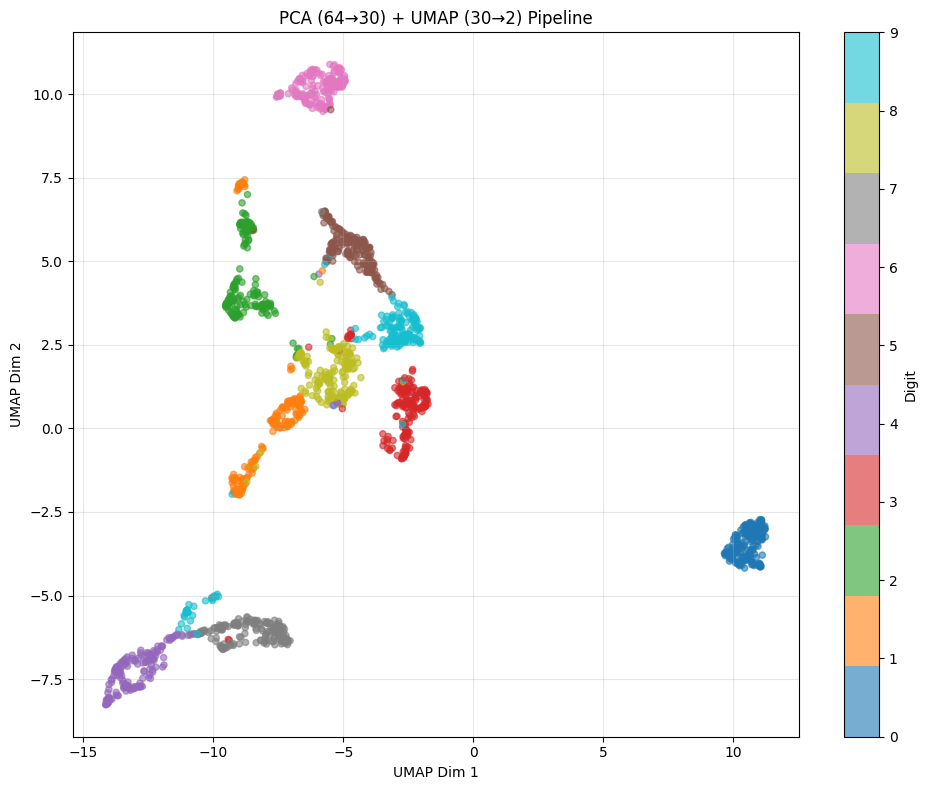

In [46]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_final[:, 0], X_final[:, 1],
                     c=y_digits, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Digit', ticks=range(10))
plt.xlabel('UMAP Dim 1')
plt.ylabel('UMAP Dim 2')
plt.title('PCA (64→30) + UMAP (30→2) Pipeline')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Key Takeaways

### Core Concepts

1. **Dimensionality reduction** transforms high-D data to low-D while preserving structure
2. **PCA** finds linear directions of maximum variance through eigendecomposition
3. **t-SNE** preserves local neighborhoods, great for visualization
4. **UMAP** balances local and global structure, faster than t-SNE

### Key Insights

- **PCA is interpretable**: Components are linear combinations of original features
- **Explained variance** tells you how much information you're keeping
- **Linear methods fail on non-linear manifolds** (Swiss roll example)
- **Perplexity** (t-SNE) and **n_neighbors** (UMAP) control local vs global balance
- **Different methods for different goals**: PCA for features, t-SNE/UMAP for viz

### Practical Applications

1. **Visualization**: Make high-dimensional data visible
2. **Feature extraction**: Speed up training, reduce overfitting
3. **Noise reduction**: Filter out noisy dimensions
4. **Preprocessing**: Often improves downstream ML performance
5. **Exploration**: Discover hidden structure and clusters

### Remember

- Start with PCA for a baseline
- Use t-SNE for beautiful visualizations
- Use UMAP for production and large datasets
- Always standardize/normalize your data first!
- No single method is "best" - choose based on your goal